In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from pathlib import Path
import os; 
from os import listdir; 
from os.path import isfile, join

In [2]:
import sys; from pathlib import Path;
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = Path(src_dir.parents[0])
from imports import * ; current_dir = Path().resolve()  ; parent_dir = current_dir.parents[1]
one_drive_dir = mi.Utilities.get_one_drive_dir()

In [3]:
working_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 linker optimization/Analysis')
results_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 linker optimization')
files = os.listdir(working_dir)
ratio_list = [file for file in files if file.endswith('.xlsx')]
print(ratio_list)
type(ratio_list)

['20240717 pNZ112_360.xlsx', '20240717 pNZ112_361.xlsx', '20240614_pNZ112_361.xlsx', '20240703 pNZ257.xlsx', '20240717 pNZ112_263.xlsx', '20240614_pNZ257.xlsx', '20240703 pNZ112_263.xlsx', '20240703 pNZ112_360.xlsx', '20240717 pNZ257.xlsx']


list

In [4]:
cells = dict()
ratio_data = []
count = 0
for file in ratio_list:
    file_path = os.path.join(working_dir, file)
    cells[count] = pd.read_excel(file_path)
    ratio_data.append(str(file_path)[-13:-5])
    count += 1
    
print("The number of cells in the folder is:",len(cells), ". Cell data is shown below.")
cells[0] 

The number of cells in the folder is: 9 . Cell data is shown below.


,Unnamed: 0,mCH,GFP,Ratio,Normalized ratio
0,Cell01,1558.693,5284.885,3.390587,4.134863
1,Cell03,2813.080,6795.174,2.415564,2.945809
2,Cell05,6765.611,19447.403,2.874449,3.505425
3,Cell06,10049.412,24057.793,2.393950,2.919452
4,Cell08,3008.936,10183.325,3.384361,4.127269
5,Cell11,7501.256,12955.257,1.727078,2.106193
6,Cell12,3995.550,11724.389,2.934362,3.578490
7,Cell17,3338.427,9348.395,2.800239,3.414926
8,Cell20,8887.152,28201.026,3.173235,3.869799
9,Cell21,6030.358,13928.137,2.309670,2.816671


In [5]:
gfpmch = [*cells[3]['Normalized ratio'], *cells[5]['Normalized ratio'], *cells[8]['Normalized ratio']]
linker5aa = [*cells[4]['Normalized ratio'], *cells[6]['Normalized ratio']]
linker9aa = [*cells[0]['Normalized ratio'], *cells[7]['Normalized ratio']]
linker13aa = [*cells[1]['Normalized ratio'], *cells[2]['Normalized ratio']]

In [6]:
print(np.mean(gfpmch), np.std(gfpmch))
print(np.mean(linker5aa), np.std(linker5aa))
print(np.mean(linker9aa), np.std(linker9aa))
print(np.mean(linker13aa), np.std(linker13aa))

1.0059232614809583 0.15575590476604265
3.4734112685887775 1.1703549576253964
3.253052122149011 0.8597635855116957
3.1994232226167663 1.170782655482497


GFP-mCh: Count = 128, Mean = 1.01, Std Dev = 0.16
5aa linker: Count = 62, Mean = 3.47, Std Dev = 1.18
9aa linker: Count = 62, Mean = 3.25, Std Dev = 0.87
13aa linker: Count = 54, Mean = 3.20, Std Dev = 1.18
Comparison GFP-mCh vs 5aa linker: p-value = 6.17e-29
Comparison GFP-mCh vs 9aa linker: p-value = 6.17e-29
Comparison GFP-mCh vs 13aa linker: p-value = 1.87e-26
Comparison 5aa linker vs 9aa linker: p-value = 5.18e-01
Comparison 5aa linker vs 13aa linker: p-value = 1.42e-01
Comparison 9aa linker vs 13aa linker: p-value = 3.10e-01


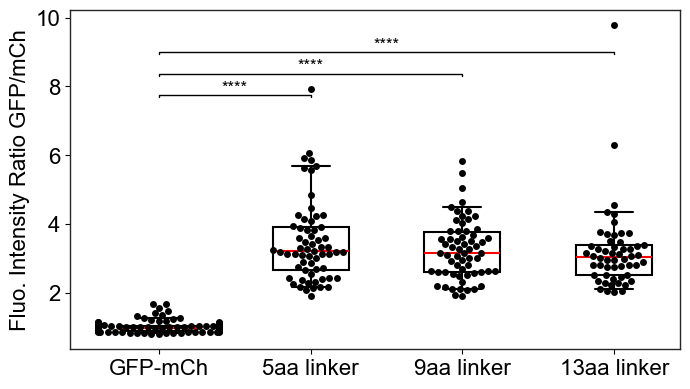

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

def plot_box_swarm_final_values(df, selected_field='Ratio', 
                                figsize=(6, 5),
                                xlabel="Construct",
                                ylabel="Fluorescent Intensity Ratio GFP/mCh",
                                title="",
                                y_min=None,
                                y_max=None,
                                swarm_color="black",
                                tick_size=12,
                                show_stats=True):
    """
    Creates a boxplot with whiskers and an overlaid swarmplot.
    The DataFrame is expected to have at least the following columns:
      - "Construct": the condition (e.g. 'GFP-mCh', '5aa linker', etc.)
      - selected_field (e.g. "Ratio"): the measurement to plot.
    
    Significance bars between adjacent groups are added using Mann–Whitney U tests.
    
    Parameters:
      df : pandas DataFrame
      selected_field : str, name of the measurement column (default "Ratio")
      figsize : tuple, figure size
      xlabel, ylabel, title : str, axis labels and plot title
      y_min, y_max : float, optional y-axis limits
      swarm_color : color for swarmplot points
      tick_size : int, font size for labels and ticks
      show_stats : bool, whether to show significance bars
      
    Returns:
      ax : matplotlib Axes object
    """
    sns.set_style("ticks")
    
    # Define the desired order for the x-axis
    order_categories = ['GFP-mCh', '5aa linker', '9aa linker', '13aa linker']

    # report the number of data points in each category and the values and std
    for category in order_categories:
        count = df[df['Construct'] == category].shape[0]
        mean_value = df[df['Construct'] == category][selected_field].mean()
        std_value = df[df['Construct'] == category][selected_field].std()
        print(f"{category}: Count = {count}, Mean = {mean_value:.2f}, Std Dev = {std_value:.2f}")
    
    # Create the figure with a white background
    plt.figure(figsize=figsize, facecolor='white')
    ax = sns.boxplot(
        x="Construct",
        y=selected_field,
        data=df,
        order=order_categories,
        showfliers=False,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'red'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        linewidth=1.5,
        whis=[5, 95],
        width=0.5,
    )
    ax.set_facecolor('white')
    
    # Overlay the swarmplot for individual points.
    sns.swarmplot(
        x="Construct",
        y=selected_field,
        data=df,
        order=order_categories,
        color=swarm_color,
        size=5,
    )
    
    # Set axis labels and title
    plt.xlabel(xlabel, fontsize=tick_size+2, fontname="Arial", color='black')
    plt.ylabel(ylabel, fontsize=tick_size+4, fontname="Arial", color='black')
    plt.title(title, fontsize=tick_size+2, fontname="Arial", color='black')
    
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    
    ax.tick_params(axis='x', labelsize=tick_size+4, colors='black')
    ax.tick_params(axis='y', labelsize=tick_size+4, colors='black')
    plt.xticks(fontname="Arial")
    plt.yticks(fontname="Arial")
    
    # Optionally add significance comparisons
    if show_stats:
        # Use y_max if provided; otherwise, compute global maximum from the data.
        if y_max is not None:
            global_max = y_max
        else:
            #global_max = df[selected_field].max()
            # use the 95th percentile as the maximum for the y-axis
            global_max = np.percentile(df[selected_field], 99.5)
        # Compute a global range; if y_min and y_max are given, use them.
        if y_min is not None and y_max is not None:
            global_range = y_max - y_min
        else:
            global_range = global_max - df[selected_field].min()
        
        offset = 0.1 * global_range  # vertical offset per comparison
        bar_height = 0.01 * global_range
        
        # Define comparisons among adjacent groups.
        # Here, we compare group0 vs group1, group1 vs group2, and group2 vs group3.
        #comparisons = [((0,1), 0), ((1,2), 1), ((2,3), 2)]
        comparisons = [((0,1), 0), ((0,2), 1), ((0,3), 2), ((1,2), 3), ((1,3), 4), ((2,3), 5)]

        for ((i, j), level) in comparisons:
            group1 = df[df['Construct'] == order_categories[i]][selected_field]
            group2 = df[df['Construct'] == order_categories[j]][selected_field]
            try:
                stat, p = mannwhitneyu(group1, group2)
            except Exception as e:
                p = np.nan
            if p < 0.0001:
                sig = '****'
            elif p < 0.001:
                sig = '***'
            elif p < 0.01:
                sig = '**'
            elif p < 0.05:
                sig = '*'
            else:
                sig = 'ns'
            # x-axis positions are taken as the integer positions (0, 1, 2, 3)
            if sig != 'ns':
                x1, x2 = i, j
                y_line = global_max + offset * (level + 1)
                ax.plot([x1, x1, x2, x2],
                        [y_line, y_line+bar_height, y_line+bar_height, y_line],
                        lw=1, c='k')
                ax.text((x1 + x2) / 2, y_line+bar_height, sig, ha='center', va='bottom',
                    color='k', fontsize=12, fontname="Arial")
            print(f"Comparison {order_categories[i]} vs {order_categories[j]}: p-value = {p:.2e}")
    
    plt.tight_layout()
    # save figure in results_dir
    plt.savefig(results_dir / f"box_swarm_{selected_field}.png", dpi=600, bbox_inches='tight', transparent=True)
    plt.savefig(results_dir / f"box_swarm_{selected_field}.svg", dpi=600, bbox_inches='tight', transparent=True)
    plt.show()
    return ax

# Create a DataFrame from the data
data = {
    'Construct': ['GFP-mCh'] * len(gfpmch) + ['5aa linker'] * len(linker5aa) + ['9aa linker'] * len(linker9aa) + ['13aa linker'] * len(linker13aa),
    'Ratio': gfpmch + linker5aa + linker9aa + linker13aa
}
df = pd.DataFrame(data)
# Call the function with the DataFrame
plot_box_swarm_final_values(df, selected_field='Ratio', 
                              figsize=(7, 4),
                              xlabel="",
                              ylabel="Fluo. Intensity Ratio GFP/mCh",
                              title="",
                              y_min=None,
                              y_max=None,
                              swarm_color="black",
                              tick_size=12,
                              show_stats=True)
plt.show()
plt.close()